In [1]:
output = """
convert_and_run(a, b, LMI._dot_product_scalar): 0.00016689899397897534 seconds per loop
convert_and_run(a, b, LMI._dot_product_avx2): 0.00006105050299083814 seconds per loop
convert_and_run(a, b, LMI._dot_product_avx2_fma): 0.00006170191100682132 seconds per loop
convert_and_run(a, b, LMI._dot_product_avx2_reg_sum): 0.00006097563999355771 seconds per loop
convert_and_run(a, b, LMI._dot_product_avx2_fma_reg_sum): 0.00006250867398921400 seconds per loop
convert_and_run(a, b, LMI._dot_product_avx512): 0.00005933171798824333 seconds per loop
LMI._dot_product_f32_f16_avx2(a, b): 0.00000944692100165412 seconds per loop

"""

In [4]:
import re
import pandas as pd

# Extract names and times using regex
pattern = r'(?:convert_and_run\(a, b, LMI\._|LMI\._)(dot_product[^:]+): (\d+\.\d+)'
matches = re.findall(pattern, output)

# Create lists of names and times
names = [match[0] for match in matches]
times = [float(match[1]) for match in matches]

print("Names:", names)
print("Times:", times)

df = pd.DataFrame({'name': names, 'time': times})

Names: ['dot_product_scalar)', 'dot_product_avx2)', 'dot_product_avx2_fma)', 'dot_product_avx2_reg_sum)', 'dot_product_avx2_fma_reg_sum)', 'dot_product_avx512)', 'dot_product_f32_f16_avx2(a, b)']
Times: [0.00016689899397897534, 6.105050299083814e-05, 6.170191100682132e-05, 6.097563999355771e-05, 6.2508673989214e-05, 5.933171798824333e-05, 9.44692100165412e-06]


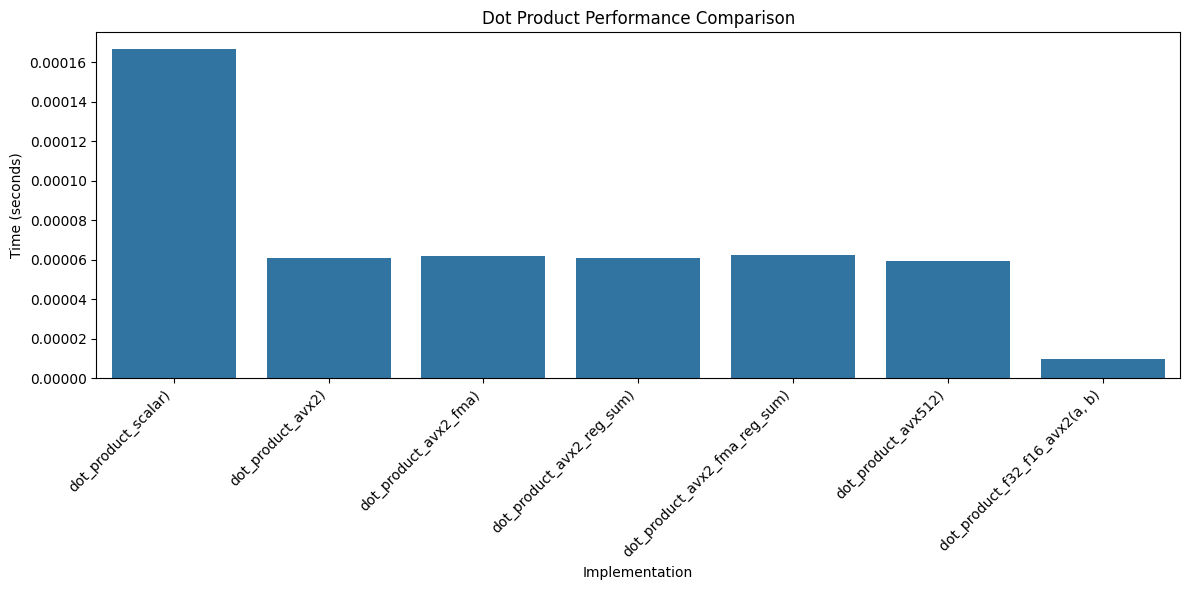

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='name', y='time')

# Customize plot
plt.xticks(rotation=45, ha='right')
plt.title('Dot Product Performance Comparison')
plt.xlabel('Implementation')
plt.ylabel('Time (seconds)')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.show()


In [6]:
# Convert times to microseconds and print
df['time_us'] = df['time'] * 1_000_000
print("\nTimes in microseconds:")
for idx, row in df.iterrows():
    print(f"{row['name']}: {row['time_us']:.2f} μs")



Times in microseconds:
dot_product_scalar): 166.90 μs
dot_product_avx2): 61.05 μs
dot_product_avx2_fma): 61.70 μs
dot_product_avx2_reg_sum): 60.98 μs
dot_product_avx2_fma_reg_sum): 62.51 μs
dot_product_avx512): 59.33 μs
dot_product_f32_f16_avx2(a, b): 9.45 μs
